In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
class Perceptron:
    
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        self.errors = []

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (target - y_pred)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

In [5]:
model = Perceptron(lr=0.01, epochs=50)
model.fit(X_train, y_train)

In [6]:
print("Final Weights:", model.weights)
print("Final Bias:", model.bias)

Final Weights: [ 0.08949549 -0.03464723]
Final Bias: 0.04


In [7]:
train_pred = model.predict(X_train)
train_accuracy = np.mean(train_pred == y_train)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [8]:
test_pred = model.predict(X_test)
test_accuracy = np.mean(test_pred == y_test)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 1.0


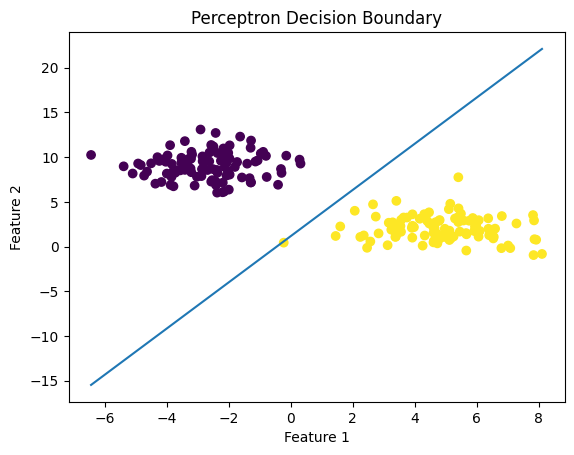

In [9]:
def plot_decision_boundary(X, y, model):
    
    plt.scatter(X[:,0], X[:,1], c=y)

    x_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)

    y_vals = -(model.weights[0]*x_vals + model.bias) / model.weights[1]

    plt.plot(x_vals, y_vals)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Perceptron Decision Boundary")

    plt.show()


plot_decision_boundary(X, y, model)

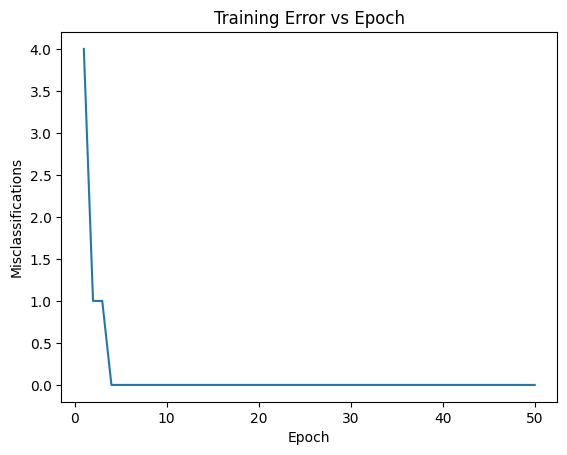

In [10]:
plt.plot(range(1, len(model.errors)+1), model.errors)
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.title("Training Error vs Epoch")
plt.show()